In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('loan_approval_data.csv')
df.head()

def generateReport(model_name, y_test, y_pred):

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    # Basic Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")

    plt.show()


In [3]:
df = df.dropna(subset=['Applicant_Income', 'Loan_Amount', 'Loan_Approved'])
df['Employment_Status'] = df['Employment_Status'].fillna(df['Employment_Status'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Marital_Status'] = df['Marital_Status'].fillna(df['Marital_Status'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].median())
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())
df['Existing_Loans'] = df['Existing_Loans'].fillna(df['Existing_Loans'].median())
df['DTI_Ratio'] = df['DTI_Ratio'].fillna(df['DTI_Ratio'].median())
df['Savings'] = df['Savings'].fillna(df['Savings'].median())
df['Collateral_Value'] = df['Collateral_Value'].fillna(df['Collateral_Value'].median())
df['Loan_Term'] = df['Loan_Term'].fillna(df['Loan_Term'].median())
df['Loan_Purpose'] = df['Loan_Purpose'].fillna(df['Loan_Purpose'].mode()[0])
df['Property_Area'] = df['Property_Area'].fillna(df['Property_Area'].mode()[0])
df['Education_Level'] = df['Education_Level'].fillna(df['Education_Level'].mode()[0])
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Employer_Category'] = df['Employer_Category'].fillna(df['Employer_Category'].mode()[0])


df['Total_Income'] = (
    df['Applicant_Income'] +
    df['Coapplicant_Income']
)

df['Total_Income'] = df['Total_Income'].fillna(df['Total_Income'].median())

df = df.drop(columns=['Applicant_ID', 'Coapplicant_Income'], errors='ignore')

In [4]:
df['Loan_Approved'] = df['Loan_Approved'].replace({
    'Yes': 1,
    'No': 0
}).astype(int)
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married': 1,
    'Single': 0
}).astype(int)
df['Education_Level'] = df['Education_Level'].replace({
    'Not Graduate': 0,
    
    'Graduate': 1
}).astype(int)
df['Gender'] = df['Gender'].replace({
    'Female': 0,
    'Male': 1
}).astype(int)

C:\Users\verma\AppData\Local\Temp\ipykernel_26216\1852040905.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Loan_Approved'] = df['Loan_Approved'].replace({
C:\Users\verma\AppData\Local\Temp\ipykernel_26216\1852040905.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Marital_Status'] = df['Marital_Status'].replace({
C:\Users\verma\AppData\Local\Temp\ipykernel_26216\1852040905.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expli

In [5]:
df = pd.get_dummies(df, columns=['Employment_Status', 'Loan_Purpose', 'Property_Area','Employer_Category' ], drop_first=True, dtype='int')

**X and Y data split**

In [6]:
X = df.drop(columns=['Loan_Approved'])
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


Standardization

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**LOGISTIC REGRESSION**


Logistic Regression
Accuracy  : 0.8256
Precision : 0.7846
Recall    : 0.6220
F1-Score  : 0.6939

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       176
           1       0.78      0.62      0.69        82

    accuracy                           0.83       258
   macro avg       0.81      0.77      0.79       258
weighted avg       0.82      0.83      0.82       258



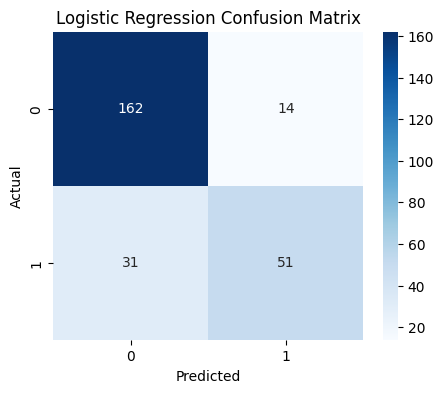

In [8]:
model_logistic = LogisticRegressionCV(
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    cv=5,
    scoring='accuracy',
)

model_logistic.fit(X_train_scaled, y_train)
y_pred_logistic = model_logistic.predict(X_test_scaled)

generateReport("Logistic Regression",y_test, y_pred_logistic)

**NAIVE BAYES**


Naive Bayes
Accuracy  : 0.8333
Precision : 0.8824
Recall    : 0.5488
F1-Score  : 0.6767

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.97      0.89       176
           1       0.88      0.55      0.68        82

    accuracy                           0.83       258
   macro avg       0.85      0.76      0.78       258
weighted avg       0.84      0.83      0.82       258



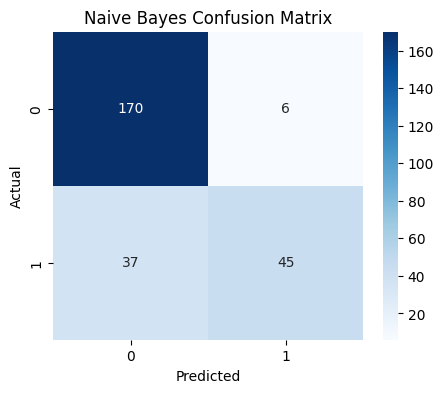

In [9]:
model_GB = GaussianNB()
model_GB.fit(X_train_scaled, y_train)
y_pred_bayes = model_GB.predict(X_test_scaled)

generateReport("Naive Bayes",y_test, y_pred_bayes)

**KNN**


KNN
Accuracy  : 0.7752
Precision : 0.7727
Recall    : 0.4146
F1-Score  : 0.5397

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.94      0.85       176
           1       0.77      0.41      0.54        82

    accuracy                           0.78       258
   macro avg       0.77      0.68      0.70       258
weighted avg       0.77      0.78      0.75       258



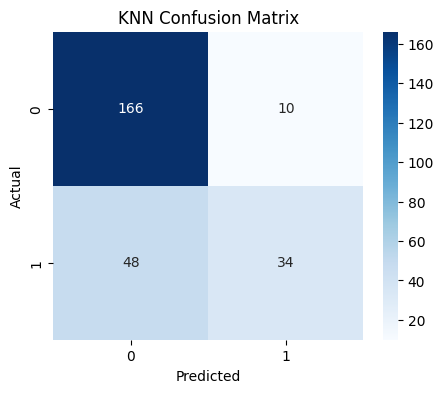

In [10]:
model_KNN = KNeighborsClassifier()

params = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]}

grid = GridSearchCV(
    estimator=model_KNN,
    param_grid=params,
    cv = 10, 
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)
y_pred_KNN = grid.predict(X_test_scaled)

generateReport("KNN" ,y_test, y_pred_KNN)



**Decision-Trees**

In [15]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(
    X_train, 
    y_train
)
alphas = path.ccp_alphas


Decision-Trees
Accuracy  : 0.9535
Precision : 0.9167
Recall    : 0.9390
F1-Score  : 0.9277

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       176
           1       0.92      0.94      0.93        82

    accuracy                           0.95       258
   macro avg       0.94      0.95      0.95       258
weighted avg       0.95      0.95      0.95       258



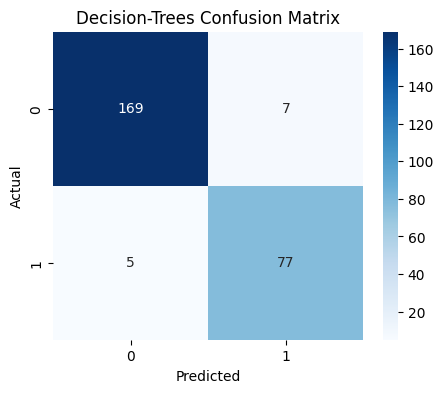

In [18]:
params = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'criterion': ['gini', 'entropy'], 
    'ccp_alpha' : alphas    
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42), 
    param_grid=params,
    cv = 5, 
    scoring='precision', 
    n_jobs=-1
)

grid.fit(X_train, y_train)

y_pred_tree = grid.predict(X_test)

generateReport("Decision-Trees", y_test, y_pred_tree)

In [20]:
print(grid.best_params_)
print(grid.score(X_train, y_train))
print(grid.score(X_test, y_test))

{'ccp_alpha': np.float64(0.005669618894256576), 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4}
0.945273631840796
0.9166666666666666
